# TerraPulse AI — Jupyter Training Notebook
**Crop Recommendation · Yield Prediction · Soil Health Monitoring**

---
Run each cell one by one using `Shift + Enter`. No changes needed — just run from top to bottom.

---

## Step 1 — Install and import libraries

In [1]:
import sys
!{sys.executable} -m pip install scikit-learn pandas numpy xgboost matplotlib seaborn -q
print('All packages ready.')

All packages ready.


'C:\Users\Roshan' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Make sure terrapulse_ai.py is in the SAME folder as this notebook
from terrapulse_ai import TerraPulseAI, SyntheticDataGenerator, SensorReading, IDEAL_CROP_PROFILES, CROP_BASE_YIELD

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
FEATURE_COLS = ['N','P','K','pH','moisture','temperature']
CROP_COLORS  = ['#378ADD','#BA7517','#EF9F27','#888780','#1D9E75','#639922','#D85A30','#E24B4A','#7F77DD','#D4537E']
print('All imports successful.')

All imports successful.


---
## Step 2 — Load dataset
Make sure `terrapulse_dataset_35k.csv` is in the **same folder** as this notebook.

In [3]:
df = pd.read_csv('terrapulse_dataset_35k.csv')
print(f'Shape         : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Crops         : {df["crop"].nunique()} unique')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head(8)

Shape         : 35,000 rows x 11 columns
Crops         : 10 unique
Missing values: 0


,sample_id,zone_id,crop,N,P,K,pH,moisture,temperature,yield_t_ha,yield_efficiency_%
0,TP-00001,3,rice,82.925284,35.008076,43.602166,6.677207,53.611304,21.093461,4.092,90.93
1,TP-00002,3,rice,76.964071,39.919354,35.905389,6.633167,76.533452,25.198092,4.311,95.80
2,TP-00003,1,rice,90.821516,42.244045,35.875396,6.265501,61.945386,27.635351,4.198,93.29
3,TP-00004,2,rice,78.225321,36.731538,45.868198,5.888739,66.402046,23.943599,4.304,95.64
4,TP-00005,2,rice,85.110168,41.754132,41.981117,6.310191,87.989840,23.780755,4.222,93.82
5,TP-00006,1,rice,72.187782,42.956701,45.419067,5.917958,62.942686,22.526556,4.219,93.76
6,TP-00007,3,rice,86.245691,43.567620,42.607140,5.520833,71.950155,25.350057,4.309,95.76
7,TP-00008,1,rice,88.365716,41.073259,43.258785,6.048657,72.428603,26.893865,4.321,96.02


In [4]:
df[FEATURE_COLS + ['yield_t_ha']].describe().round(2)

,N,P,K,pH,moisture,temperature,yield_t_ha
count,35000.00,35000.00,35000.00,35000.00,35000.00,35000.00,35000.00
mean,81.99,56.50,58.07,6.27,56.96,23.40,17.69
std,33.23,15.12,30.97,0.83,13.59,4.61,20.44
min,10.66,21.25,11.41,3.50,18.91,7.36,1.26
25%,59.57,43.61,38.32,5.71,47.24,19.88,2.61
50%,87.17,55.79,45.75,6.27,56.66,23.32,4.46
75%,106.77,66.44,79.33,6.82,66.68,26.71,32.65
max,168.47,124.93,174.49,9.00,100.00,40.53,68.96


---
## Step 3 — Explore the dataset

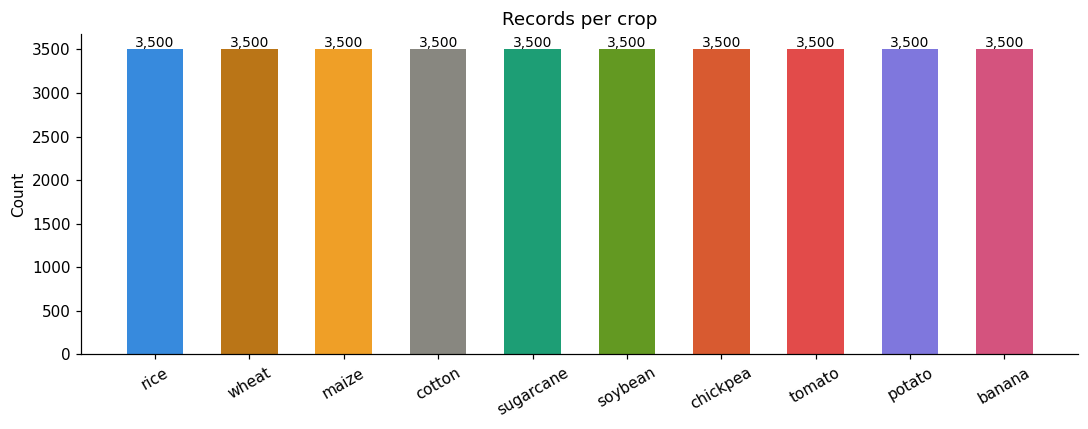

In [5]:
# Records per crop
crop_counts = df['crop'].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(crop_counts.index, crop_counts.values, color=CROP_COLORS, width=0.6)
for bar, val in zip(bars, crop_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, f'{val:,}', ha='center', fontsize=9)
ax.set_title('Records per crop')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

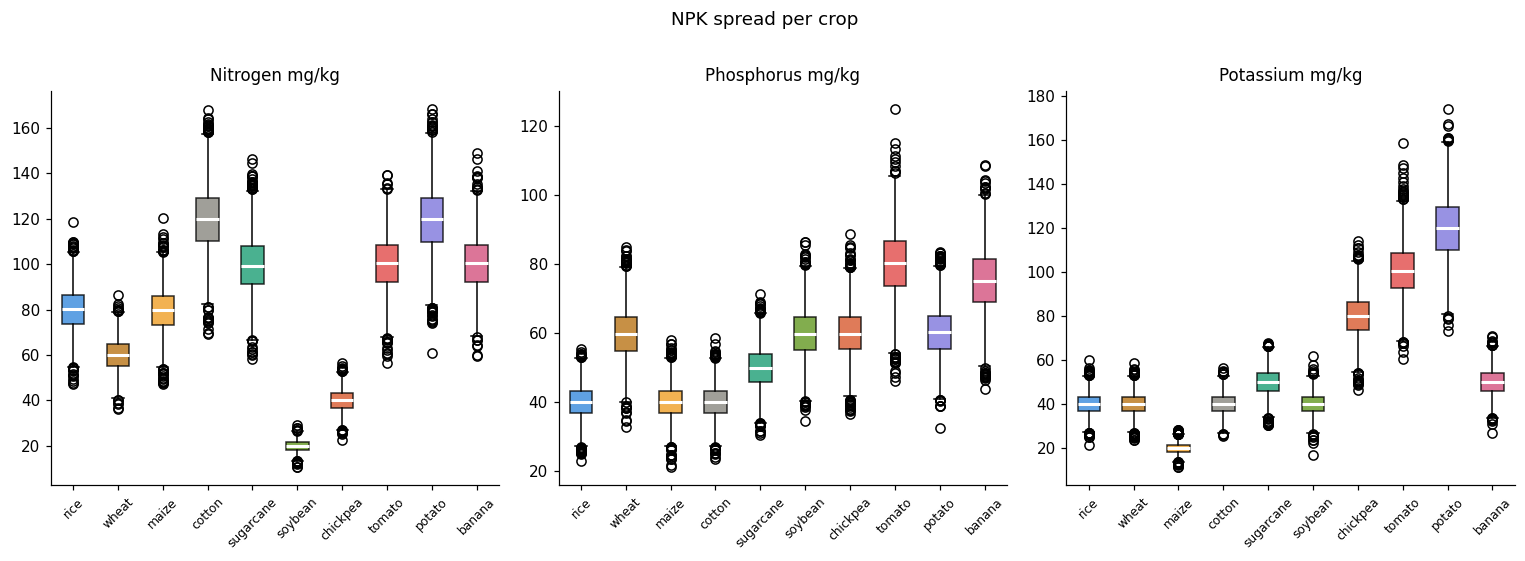

In [6]:
# NPK box plots per crop
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, feat, title in zip(axes, ['N','P','K'], ['Nitrogen mg/kg','Phosphorus mg/kg','Potassium mg/kg']):
    data_by_crop = [df[df['crop']==c][feat].values for c in df['crop'].unique()]
    bp = ax.boxplot(data_by_crop, patch_artist=True, labels=df['crop'].unique(),
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], CROP_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.suptitle('NPK spread per crop', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

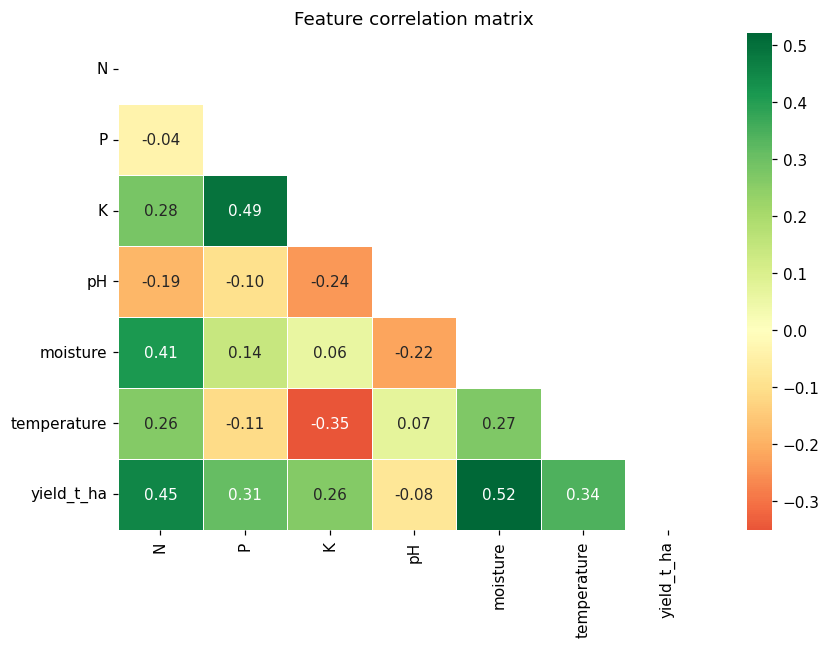

In [7]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[FEATURE_COLS + ['yield_t_ha']].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

---
## Step 4 — Train the full TerraPulse AI system
Trains both Crop Classifier and Yield Regressor.

In [8]:
ai = TerraPulseAI()
ai.train(df)
print('Training complete. Both models ready.')

22:07:56 [INFO] TerraPulse — TerraPulse AI initialised.
22:07:56 [INFO] TerraPulse — ════════════════════════════════════════════════════════════
22:07:56 [INFO] TerraPulse — Training CropRecommender …
22:07:58 [INFO] TerraPulse — 
              precision    recall  f1-score   support

      banana       0.97      0.96      0.96       663
    chickpea       1.00      1.00      1.00       737
      cotton       0.97      0.98      0.97       686
       maize       1.00      1.00      1.00       711
      potato       0.98      0.99      0.98       717
        rice       0.94      0.94      0.94       711
     soybean       1.00      1.00      1.00       713
   sugarcane       0.90      0.90      0.90       689
      tomato       0.99      0.97      0.98       679
       wheat       0.99      0.99      0.99       694

    accuracy                           0.97      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.97      0.97      0.97      7000

22:07:58 

Training complete. Both models ready.


---
## Step 5 — Confusion matrix and feature importance

In [9]:
scaler_e = StandardScaler()
enc_e    = LabelEncoder()
X_e = scaler_e.fit_transform(df[FEATURE_COLS])
y_e = enc_e.fit_transform(df['crop'])
X_tr, X_val, y_tr, y_val = train_test_split(X_e, y_e, test_size=0.2, random_state=42)
clf_e = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf_e.fit(X_tr, y_tr)
y_pred = clf_e.predict(X_val)
print(classification_report(y_val, y_pred, target_names=enc_e.classes_))

              precision    recall  f1-score   support

      banana       0.97      0.96      0.96       663
    chickpea       1.00      1.00      1.00       737
      cotton       0.97      0.98      0.97       686
       maize       1.00      1.00      1.00       711
      potato       0.98      0.98      0.98       717
        rice       0.94      0.94      0.94       711
     soybean       1.00      1.00      1.00       713
   sugarcane       0.89      0.90      0.90       689
      tomato       0.98      0.97      0.98       679
       wheat       0.99      0.99      0.99       694

    accuracy                           0.97      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.97      0.97      0.97      7000



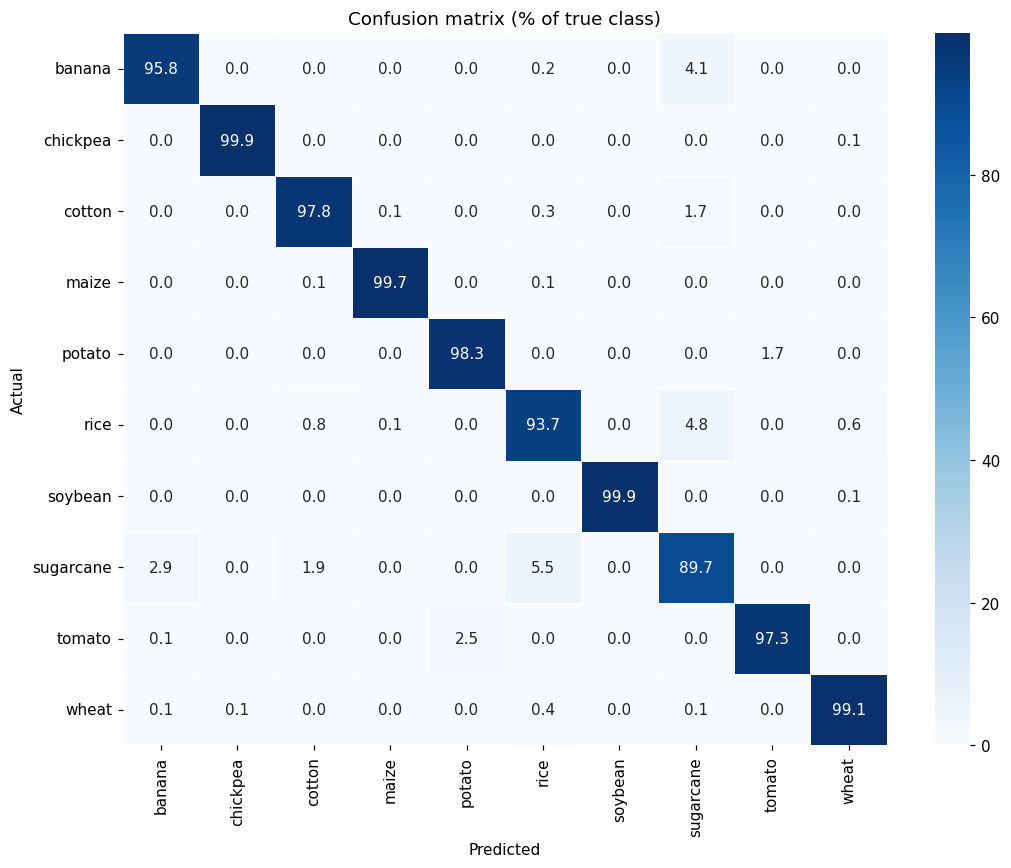

Overall accuracy: 97.16%


In [10]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=enc_e.classes_, yticklabels=enc_e.classes_,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix (% of true class)')
plt.tight_layout()
plt.show()
print(f'Overall accuracy: {(y_pred==y_val).mean()*100:.2f}%')

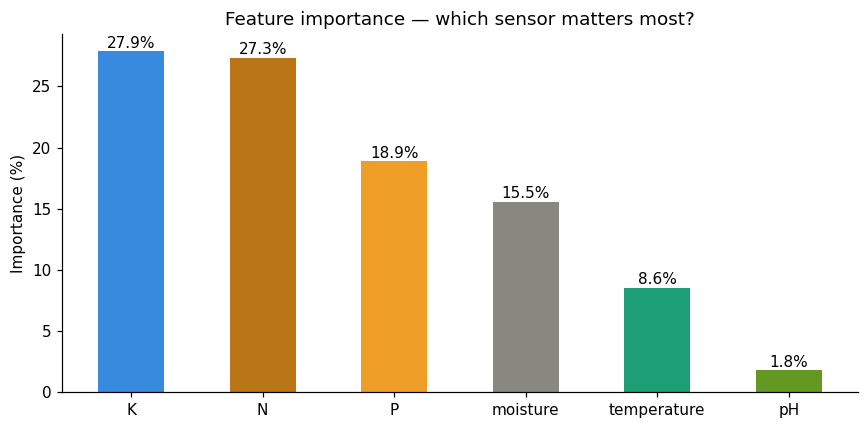

In [11]:
# Feature importance
importances = clf_e.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
sorted_feat = [FEATURE_COLS[i] for i in sorted_idx]
sorted_imp  = importances[sorted_idx]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sorted_feat, sorted_imp*100, color=CROP_COLORS[:6], width=0.5)
for i, (f, v) in enumerate(zip(sorted_feat, sorted_imp)):
    ax.text(i, v*100+0.3, f'{v*100:.1f}%', ha='center', fontsize=10)
ax.set_title('Feature importance — which sensor matters most?')
ax.set_ylabel('Importance (%)')
plt.tight_layout()
plt.show()

---
## Step 6 — Yield predictor evaluation

In [12]:
enc_y = LabelEncoder()
sc_y  = StandardScaler()
df_y  = df.copy()
df_y['crop_enc'] = enc_y.fit_transform(df_y['crop'])
feat_y = FEATURE_COLS + ['crop_enc']
X_y = sc_y.fit_transform(df_y[feat_y])
y_y = df_y['yield_t_ha'].values
X_tr_y, X_val_y, y_tr_y, y_val_y = train_test_split(X_y, y_y, test_size=0.2, random_state=42)
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, random_state=42, verbosity=0)
xgb.fit(X_tr_y, y_tr_y)
y_pred_y = xgb.predict(X_val_y)
mae = mean_absolute_error(y_val_y, y_pred_y)
r2  = r2_score(y_val_y, y_pred_y)
print(f'MAE : {mae:.3f} t/ha')
print(f'R2  : {r2:.4f}')

MAE : 0.151 t/ha
R2  : 0.9987


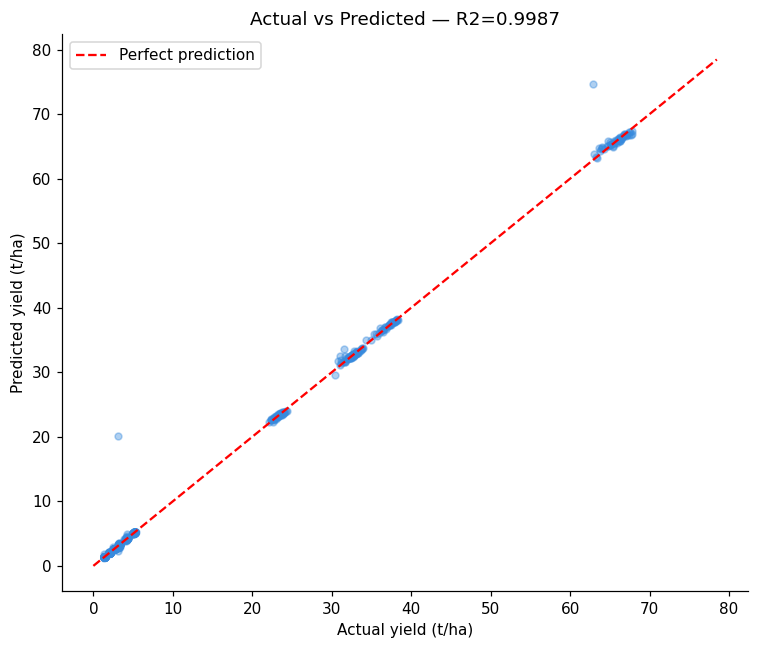

In [13]:
# Actual vs Predicted scatter
idx = np.random.choice(len(y_val_y), 500, replace=False)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_val_y[idx], y_pred_y[idx], alpha=0.4, color='#378ADD', s=20)
lims = [0, max(y_val_y.max(), y_pred_y.max())*1.05]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual yield (t/ha)')
ax.set_ylabel('Predicted yield (t/ha)')
ax.set_title(f'Actual vs Predicted — R2={r2:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 7 — Run live predictions with your sensor values

In [14]:
# Change these values to your real sensor readings
my_reading = SensorReading(
    zone_id=1, N=55.0, P=40.0, K=38.0,
    pH=5.9, moisture=42.0, temperature=23.0
)

result = ai.run(my_reading)
rec = result['recommendation']
yld = result['yield_forecast']
cmd = result['actuation_command']

print(f"Recommended Crop : {rec['recommended_crop'].upper()}")
print(f"Confidence       : {rec['confidence']*100:.1f}%")
print(f"Predicted Yield  : {yld['predicted_yield']} t/ha")
print(f"Pump             : {cmd['pump']}")
print(f"Mix              : {cmd['mix']}")
print(f"Reason           : {cmd['reason']}")

print('\nTop 3 candidates:')
for c in rec['top_3_candidates']:
    bar = 'I' * int(c['confidence']*30)
    print(f"  {c['crop']:<12} {bar} {c['confidence']*100:.1f}%")

22:08:51 [INFO] TerraPulse — Zone 1 | Smoothed reading applied.
22:08:51 [INFO] TerraPulse — Zone 1 | Recommended crop: rice (confidence: 44.1%)
22:08:51 [INFO] TerraPulse — Zone 1 | Predicted yield: 3.78 t/ha (84.0% efficiency)
22:08:51 [WARNING] TerraPulse — Zone 1 | 'N' DEFICIENT: current=55.00, ideal=80.00, shortfall=31.2%
22:08:51 [WARNING] TerraPulse — Zone 1 | 'moisture' DEFICIENT: current=42.00, ideal=70.00, shortfall=40.0%
22:08:51 [INFO] TerraPulse — Zone 1 | Actuation: pump=ON, mix=water


Recommended Crop : RICE
Confidence       : 44.1%
Predicted Yield  : 3.78 t/ha
Pump             : ON
Mix              : water
Reason           : Soil moisture critically low (42.0% vs ideal 70%). Activating irrigation pump.

Top 3 candidates:
  rice         IIIIIIIIIIIII 44.1%
  wheat        IIIIIIIIII 36.3%
  cotton       III 11.3%


In [15]:
# All 3 zones at once
zone_readings = [
    SensorReading(zone_id=1, N=58, P=57, K=39, pH=6.4, moisture=38.0, temperature=19),
    SensorReading(zone_id=2, N=52, P=38, K=18, pH=6.6, moisture=54.0, temperature=22),
    SensorReading(zone_id=3, N=76, P=38, K=37, pH=4.8, moisture=67.0, temperature=25),
]
results = ai.run_all_zones(zone_readings)
rows = []
for r in results:
    if 'error' not in r:
        rows.append({'Zone': r['zone_id'],
                     'Crop': r['recommendation']['recommended_crop'],
                     'Confidence': f"{r['recommendation']['confidence']*100:.1f}%",
                     'Yield t/ha': r['yield_forecast']['predicted_yield'],
                     'Pump': r['actuation_command']['pump'],
                     'Mix': r['actuation_command']['mix']})
pd.DataFrame(rows).set_index('Zone')

22:09:02 [INFO] TerraPulse — Zone 1 | Smoothed reading applied.
22:09:02 [INFO] TerraPulse — Zone 1 | Recommended crop: wheat (confidence: 75.6%)
22:09:02 [INFO] TerraPulse — Zone 1 | Predicted yield: 3.152 t/ha (90.1% efficiency)
22:09:02 [WARNING] TerraPulse — Zone 1 | 'P' DEFICIENT: current=44.23, ideal=60.00, shortfall=26.3%
22:09:02 [WARNING] TerraPulse — Zone 1 | 'moisture' DEFICIENT: current=41.00, ideal=50.00, shortfall=18.0%
22:09:02 [INFO] TerraPulse — Zone 1 | Actuation: pump=ON, mix=water
22:09:02 [INFO] TerraPulse — Zone 2 | Smoothed reading applied.
22:09:03 [INFO] TerraPulse — Zone 2 | Recommended crop: maize (confidence: 98.5%)
22:09:03 [INFO] TerraPulse — Zone 2 | Predicted yield: 4.926 t/ha (89.6% efficiency)
22:09:03 [WARNING] TerraPulse — Zone 2 | 'N' DEFICIENT: current=52.00, ideal=80.00, shortfall=35.0%
22:09:03 [INFO] TerraPulse — Zone 2 | Actuation: pump=ON, mix=fertilizer
22:09:03 [INFO] TerraPulse — Zone 3 | Smoothed reading applied.
22:09:03 [INFO] TerraPulse

,Crop,Confidence,Yield t/ha,Pump,Mix
Zone,,,,,
1,wheat,75.6%,3.152,ON,water
2,maize,98.5%,4.926,ON,fertilizer
3,rice,100.0%,4.519,ON,pH_up


---
## Step 8 — Save trained models to disk
Save once, load instantly next time. No retraining needed.

In [16]:
import os
with open('terrapulse_recommender.pkl','wb') as f: pickle.dump(ai.recommender, f)
with open('terrapulse_predictor.pkl','wb')  as f: pickle.dump(ai.predictor, f)
print(f'Recommender saved: {os.path.getsize("terrapulse_recommender.pkl")/1024/1024:.1f} MB')
print(f'Predictor saved  : {os.path.getsize("terrapulse_predictor.pkl")/1024/1024:.1f} MB')
print('Done. Next time load with pickle.load() instead of retraining.')

Recommender saved: 46.7 MB
Predictor saved  : 1.3 MB
Done. Next time load with pickle.load() instead of retraining.


In [17]:
# HOW TO LOAD SAVED MODELS NEXT TIME (skip retraining)
# Uncomment all lines below and run this cell instead of Step 4

# ai2 = TerraPulseAI()
# with open('terrapulse_recommender.pkl','rb') as f:
#     ai2.recommender = pickle.load(f)
# with open('terrapulse_predictor.pkl','rb') as f:
#     ai2.predictor = pickle.load(f)
# ai2._trained = True
# print('Models loaded in < 1 second. Ready.')

---
## Step 9 — Ideal crop profile reference


In [18]:
rows = []
for crop, p in IDEAL_CROP_PROFILES.items():
    rows.append({'Crop':crop,'N':p['N'],'P':p['P'],'K':p['K'],
                 'pH':p['pH'],'Moisture %':p['moisture'],
                 'Temp C':p['temperature'],
                 'Base Yield':f"{CROP_BASE_YIELD[crop]} t/ha"})
pd.DataFrame(rows).set_index('Crop').style.background_gradient(
    subset=['N','P','K','Moisture %'], cmap='YlGn')

,N,P,K,pH,Moisture %,Temp C,Base Yield
Crop,,,,,,,
rice,80,40,40,6.000000,70,25,4.5 t/ha
wheat,60,60,40,6.500000,50,20,3.5 t/ha
maize,80,40,20,6.500000,55,22,5.5 t/ha
cotton,120,40,40,6.500000,45,28,2.2 t/ha
sugarcane,100,50,50,6.500000,65,28,70.0 t/ha
soybean,20,60,40,6.500000,50,24,2.8 t/ha
chickpea,40,60,80,6.500000,35,18,1.5 t/ha
tomato,100,80,100,6.200000,60,24,35.0 t/ha
potato,120,60,120,5.500000,65,18,25.0 t/ha


---
## Done!

| File | Purpose |
|---|---|
| `terrapulse_recommender.pkl` | Crop classifier — load next time |
| `terrapulse_predictor.pkl` | Yield regressor — load next time |

Copy both `.pkl` files to your farm folder and load them in `terrapulse_ai.py` to skip retraining on every boot.